In [8]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from typing import TypedDict, Annotated

from langchain_groq import ChatGroq
from langchain_core.messages import BaseMessage, HumanMessage

from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool

from dotenv import load_dotenv
load_dotenv()

True

In [9]:
import yfinance as yf

In [10]:
# model
model = ChatGroq(model="llama-3.1-8b-instant", temperature=0.4)

In [23]:
# Tools

search_tool = DuckDuckGoSearchRun(region = "us-en")

@tool
def calculator_tool(operation: str, numbers: str) -> float:
    """
    Perform basic math operations on any number of values.
    
    Args:
        operation: The operation to perform (add, subtract, multiply, divide)
        numbers: Comma-separated numbers like "5,10,15"
    
    Returns:
        The result of the calculation
    
    Example:
        calculator("add", "5,10,15") → 30.0
        calculator("multiply", "2,3,4") → 24.0
    """
    
    # Convert string of numbers to list of floats
    num_list = [float(x.strip()) for x in numbers.split(",")]
    
    # Perform the operation
    if operation.lower() == "add":
        result = sum(num_list)
    
    elif operation.lower() == "subtract":
        result = num_list[0]
        for num in num_list[1:]:
            result -= num
    
    elif operation.lower() == "multiply":
        result = 1
        for num in num_list:
            result *= num
    
    elif operation.lower() == "divide":
        result = num_list[0]
        for num in num_list[1:]:
            if num == 0:
                return "Error: Cannot divide by zero"
            result /= num
    
    else:
        return f"Error: Unknown operation '{operation}'. Use add, subtract, multiply, or divide."
    
    return result

@tool
def get_stock_price(ticker: str) -> str:
    """
    Get the current stock price and basic information for a given ticker symbol.
    
    Args:
        ticker: Stock ticker symbol (e.g., "AAPL" for Apple, "GOOGL" for Google)
    
    Returns:
        Current price and basic stock information as a string
    """
    
    try:
        # Fetch stock data
        stock = yf.Ticker(ticker.upper())
        
        # Get current info
        info = stock.info
        
        # Get current price (try different fields as they vary)
        current_price = info.get('currentPrice') or info.get('regularMarketPrice') or info.get('previousClose')
        
        if current_price is None:
            return f"Could not fetch price for ticker '{ticker}'. Make sure it's a valid stock symbol."
        
        # Build response
        company_name = info.get('longName', ticker)
        currency = info.get('currency', 'USD')
        market_cap = info.get('marketCap', 'N/A')
        
        result = f"""
Stock: {company_name} ({ticker.upper()})
Current Price: {current_price} {currency}
Market Cap: {market_cap}
"""
        return result.strip()
        
    except Exception as e:
        return f"Error fetching stock data for '{ticker}': {str(e)}"

In [24]:
tools = [search_tool, get_stock_price, calculator_tool]

# llm with tools
llm_with_tools = model.bind_tools(tools)

In [25]:
# state
class ChatState(TypedDict):

      messages : Annotated[list[BaseMessage], add_messages]

In [26]:
def main_llm_function(state : ChatState) -> ChatState:

      # take user quey from state
      messages = state['messages']

      # send query to llm
      response = llm_with_tools.invoke(messages)

      # save response in the state
      return {"messages" : [response]}

tool_node = ToolNode(tools)

In [39]:
# create graph
graph = StateGraph(ChatState)

# add nodes
graph.add_node("main_llm_function", main_llm_function)
graph.add_node("tools", tool_node)

# add edges
graph.add_edge(START, "main_llm_function")
graph.add_conditional_edges("main_llm_function", tools_condition)
graph.add_edge("tools", "main_llm_function")
# compile
chatbot = graph.compile()

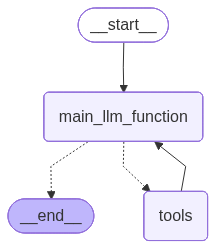

In [40]:
from IPython.display import Image
Image(chatbot.get_graph().draw_mermaid_png())

In [43]:
# Regular chat
out = chatbot.invoke({"messages": [HumanMessage(content="Hello!")]})

print(out["messages"][-1].content)

I'm happy to help you with any questions or tasks you have. What would you like to do today?


In [44]:
out = chatbot.invoke({"messages": [HumanMessage(content="what will be the output of 234 * 678 * 5")]})
print(out["messages"][-1].content)

The output of the operation 234 * 678 * 5 is 793260.0.


In [ ]:
out = chatbot.invoke({"messages": [HumanMessage(content="what is the stock price of the company that owns YouTube")]})
print(out["messages"][-1].content)

The current stock price of Alphabet Inc. (GOOGL), the parent company of YouTube, is 313.51 USD.


In [ ]:
out = chatbot.invoke({"messages": [HumanMessage(content="what will be the output of 234 * 678 / 11 * 11 * 11 * 11 * 11 * 11 * 11 * 11 * 11 * 11")]})
print(out["messages"][-1].content)

However, the correct calculation is:

(234 * 678) / 11 = 15288.0
15288.0 * 11 = 168168.0
168168.0 * 11 = 1849848.0
1849848.0 * 11 = 20348528.0
20348528.0 * 11 = 223733808.0
223733808.0 * 11 = 2464028888.0
2464028888.0 * 11 = 27124207788.0
27124207788.0 * 11 = 298467685688.0
298467685688.0 * 11 = 3288133541578.0

So the final answer is: 3288133541578.0


In [42]:
out = chatbot.invoke({"messages": [HumanMessage(content="what is the stock price of the company that owns YouTube, and how much it costs in rupees to buy the 10 share")]})
print(out["messages"][-1].content)

e:\_Projects\GAIP\.venv\Lib\site-packages\langchain_community\utilities\duckduckgo_search.py:63: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:


The current stock price of Alphabet Inc. (GOOGL) is 313.51 USD. To buy 10 shares of GOOGL in rupees, the cost would be approximately 0.031896909189499535 * 10 = 0.31986909189199499 rupees.
